## Smoothing 

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
img = cv2.imread("grayscale1.jpg", cv2.IMREAD_GRAYSCALE)

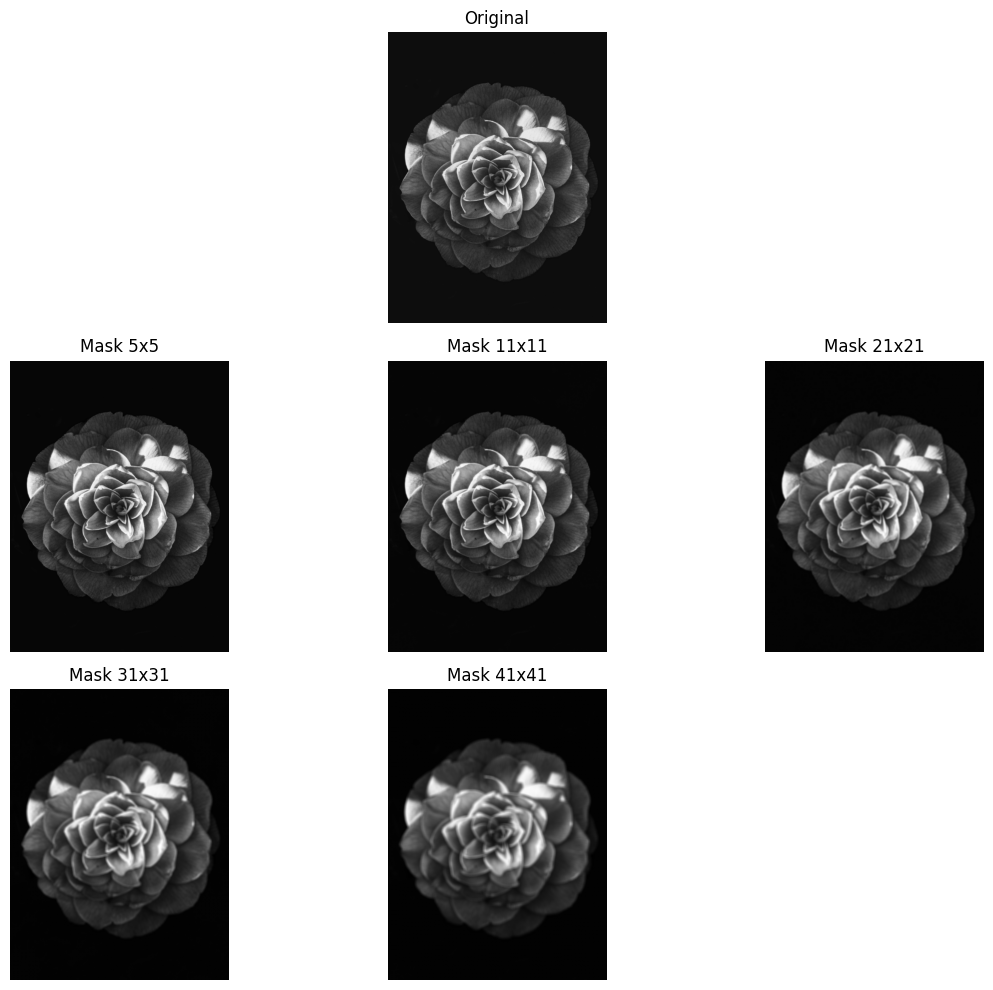

In [ ]:
# kernel_sizes = [5, 7, 9, 11, 13]
kernel_sizes = [5, 11, 21, 31, 41]

filtered_images = []
difference_images = []

for k in kernel_sizes:
    mask = np.ones((k, k), dtype=np.float32) / (k * k)

    filtered = cv2.filter2D(img, -1, mask)

    filtered_images.append(filtered)

    diff = cv2.absdiff(img, filtered)
    difference_images.append(diff)

plt.figure(figsize=(12, 10))

plt.subplot(3, 3, 2)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, f_img in enumerate(filtered_images):
    plt.subplot(3, 3, i + 4)
    plt.imshow(f_img, cmap='gray')
    plt.title(f'Mask {kernel_sizes[i]}x{kernel_sizes[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()


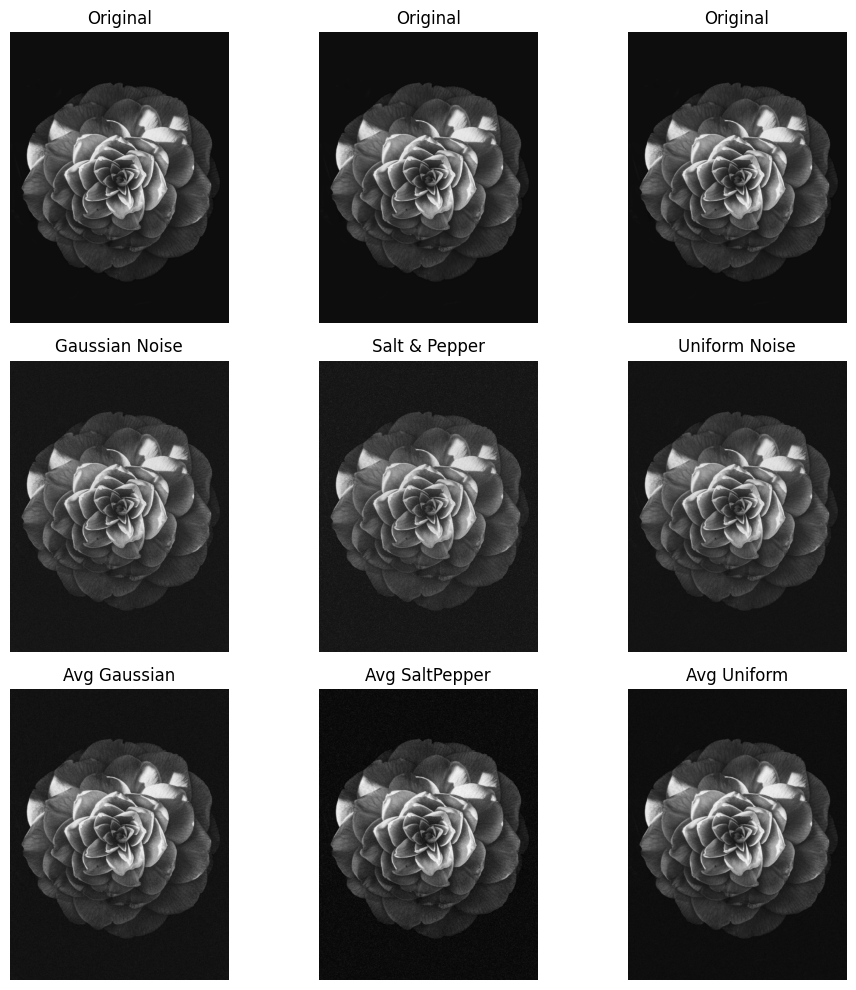

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('grayscale1.jpg', cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32) / 255.0  

def gaussian_noise(image):
    mean = 0
    std = 0.1
    gauss = np.random.normal(mean, std, image.shape)
    noisy = image + gauss
    return np.clip(noisy, 0, 1)

def salt_pepper_noise(image):
    noisy = image.copy()
    prob = 0.02
    rnd = np.random.rand(*image.shape)

    noisy[rnd < prob] = 0
    noisy[rnd > 1 - prob] = 1
    return noisy

def uniform_noise(image):
    noise = np.random.uniform(-0.1, 0.1, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 1)

g_noise = gaussian_noise(img)
sp_noise = salt_pepper_noise(img)
u_noise = uniform_noise(img)

kernel = np.ones((5,5), np.float32) / 25

def avg_filter(image):
    return cv2.filter2D(image, -1, kernel)

g_avg = avg_filter(g_noise)
sp_avg = avg_filter(sp_noise)
u_avg = avg_filter(u_noise)

images = [
    img, img, img,
    g_noise, sp_noise, u_noise,
    g_avg, sp_avg, u_avg
]

titles = [
    "Original", "Original", "Original",
    "Gaussian Noise", "Salt & Pepper", "Uniform Noise",
    "Avg Gaussian", "Avg SaltPepper", "Avg Uniform"
]

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


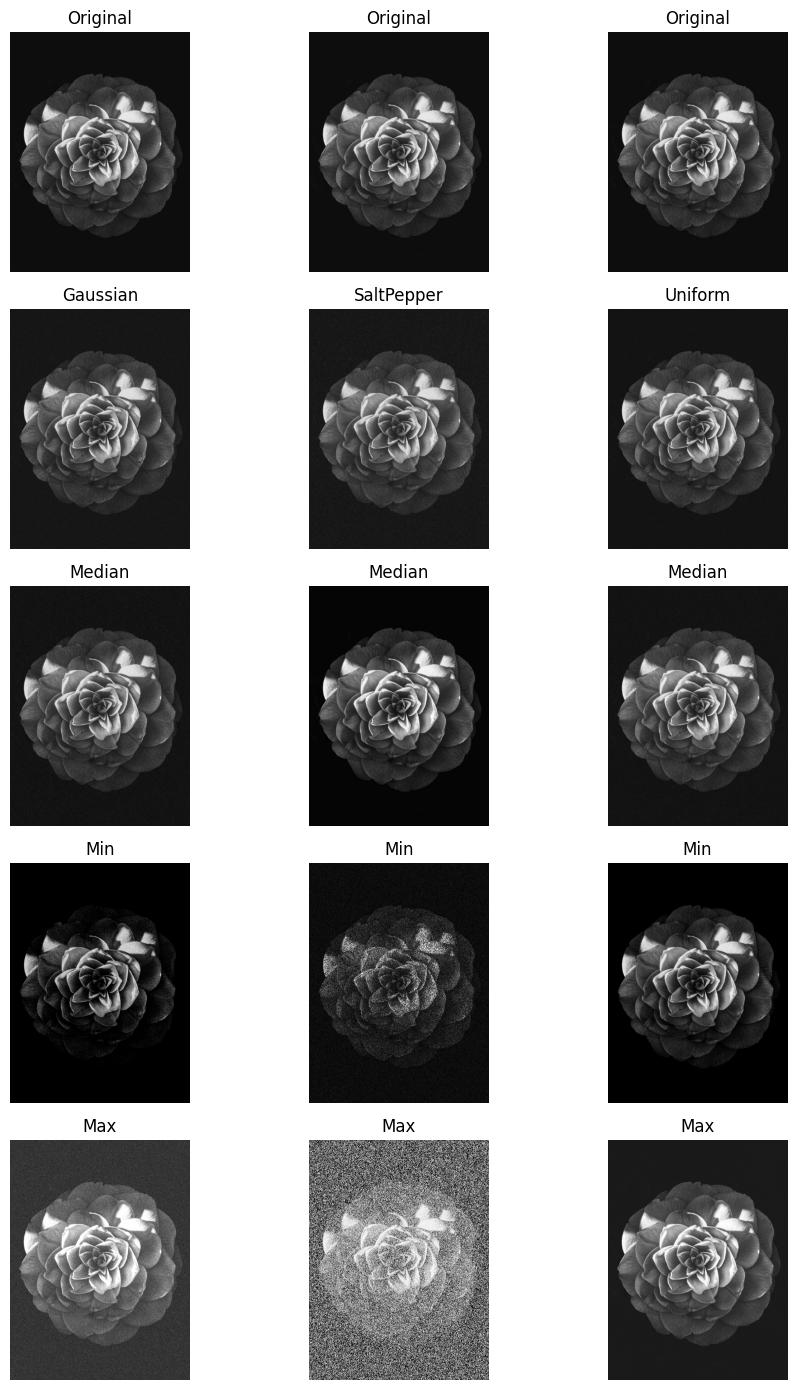

In [ ]:
def median_filter(image):
    return cv2.medianBlur((image*255).astype(np.uint8), 5) / 255.0

def min_filter(image):
    return cv2.erode(image, np.ones((5,5)))

def max_filter(image):
    return cv2.dilate(image, np.ones((5,5)))

g_med, sp_med, u_med = median_filter(g_noise), median_filter(sp_noise), median_filter(u_noise)
g_min, sp_min, u_min = min_filter(g_noise), min_filter(sp_noise), min_filter(u_noise)
g_max, sp_max, u_max = max_filter(g_noise), max_filter(sp_noise), max_filter(u_noise)


images = [
    img, img, img,
    g_noise, sp_noise, u_noise,
    g_med, sp_med, u_med,
    g_min, sp_min, u_min,
    g_max, sp_max, u_max
]

titles = [
    "Original","Original","Original",
    "Gaussian","SaltPepper","Uniform",
    "Median","Median","Median",
    "Min","Min","Min",
    "Max","Max","Max"
]

plt.figure(figsize=(10,14))
for i in range(15):
    plt.subplot(5,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
def MAE(original, processed):
    return np.mean(np.abs(original - processed))

def SNR(original, processed):
    signal_power = np.mean(original ** 2)
    noise_power = np.mean((original - processed) ** 2)
    
    if noise_power == 0:
        return float('inf')
        
    return 10 * np.log10(signal_power / noise_power)


In [21]:
results = {
    "Gaussian Median": (g_med),
    "SaltPepper Median": (sp_med),
    "Uniform Median": (u_med),
    "Gaussian Min": (g_min),
    "SaltPepper Min": (sp_min),
    "Uniform Min": (u_min),
    "Gaussian Max": (g_max),
    "SaltPepper Max": (sp_max),
    "Uniform Max": (u_max)
}

print("----- IMAGE QUALITY METRICS -----\n")

for name, image in results.items():
    mae_val = MAE(img, image)
    snr_val = SNR(img, image)
    print(f"{name}")
    print(f"MAE: {mae_val:.5f}")
    print(f"SNR: {snr_val:.2f} dB\n")


----- IMAGE QUALITY METRICS -----

Gaussian Median
MAE: 0.02183
SNR: 19.52 dB

SaltPepper Median
MAE: 0.00580
SNR: 27.22 dB

Uniform Median
MAE: 0.01773
SNR: 21.32 dB

Gaussian Min
MAE: 0.12769
SNR: 5.21 dB

SaltPepper Min
MAE: 0.08671
SNR: 3.88 dB

Uniform Min
MAE: 0.09079
SNR: 8.79 dB

Gaussian Max
MAE: 0.19777
SNR: 2.12 dB

SaltPepper Max
MAE: 0.33199
SNR: -6.00 dB

Uniform Max
MAE: 0.09967
SNR: 8.12 dB

